# Layer / sublayer / head redundancy — analysis

Visualises the score files written by `../layer_priority.py` for one
`{model}_{dataset}` stem. Read `../LAYER_PRIORITY.md` for what each metric means.

Low `bi_*` = redundant = safe to drop. Sanity check: `bi_block` should trend
**down with depth** (deeper blocks are the most redundant).

`skip` convention (matches SkipModel): a pair `(skip_from, skip_to)` keeps block
`skip_from`, drops blocks `skip_from+1 .. skip_to`, and bridges their outputs. Both
indices are in `0 .. num_layers-1`. To drop a single block `j` you write `(j-1, j)`.


In [40]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ---- point these at your run ----
OUTPUT_DIR = Path("../outputs")
STEM = "raddino_dermamnist"     # {model}_{dataset}
# ---------------------------------

def _p(suffix):
    return OUTPUT_DIR / f"{STEM}_{suffix}"

def load_block_scores(path):
    # Two sections in one file; switch on the header token (robust to missing blank line).
    block, span, mode = {}, {}, None
    for r in csv.reader(open(path)):
        if not r or not r[0]:
            continue
        if r[0] == "block":
            mode = "block"; continue
        if r[0] == "blocks_dropped":
            mode = "span"; continue
        if mode == "block":
            block[int(r[0])] = (float(r[1]), float(r[2]))
        elif mode == "span":
            span[int(r[0])] = (int(r[1]), int(r[2]), float(r[3]))
    return block, span

block, span = load_block_scores(_p("block_scores.csv"))
angdist = np.load(_p("angdist.npy"))
cka = np.load(_p("cka.npy"))
sub_path = _p("sublayer_scores.csv")
sub = {int(r[0]): tuple(map(float, r[1:])) for r in list(csv.reader(open(sub_path)))[1:]} if sub_path.exists() else {}
head_path = _p("head_similarity.npy")
head_sim = np.load(head_path) if head_path.exists() else None

L = len(block)
print(f"{STEM}: {L} blocks | sublayer split: {bool(sub)} | heads: {head_sim.shape if head_sim is not None else None}")

raddino_dermamnist: 12 blocks | sublayer split: True | heads: (12, 12, 12)


## Block Influence vs depth
Lowest bars = safest whole blocks to skip. Drop block `j` with `skip=[(j-1, j)]`.

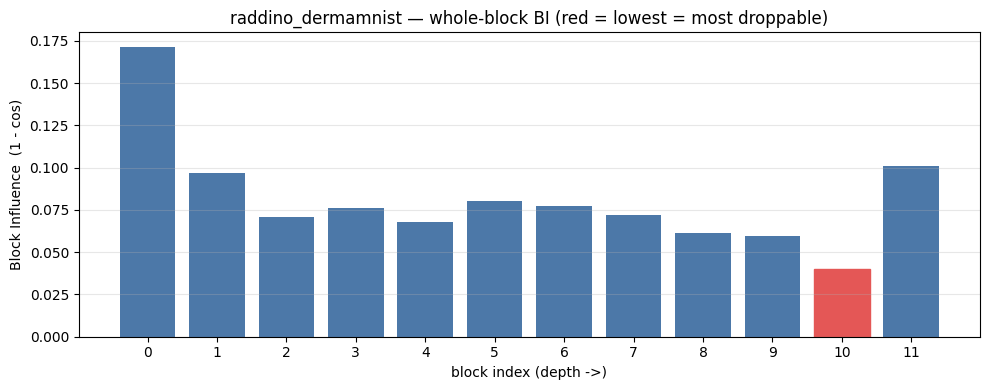

Blocks ranked most -> least droppable (skip pair to drop that single block):
  block 10   BI = 0.0403   skip = [(9, 10)]
  block  9   BI = 0.0594   skip = [(8, 9)]
  block  8   BI = 0.0612   skip = [(7, 8)]
  block  4   BI = 0.0680   skip = [(3, 4)]
  block  2   BI = 0.0711   skip = [(1, 2)]
  block  7   BI = 0.0721   skip = [(6, 7)]
  block  3   BI = 0.0763   skip = [(2, 3)]
  block  6   BI = 0.0775   skip = [(5, 6)]
  block  5   BI = 0.0806   skip = [(4, 5)]
  block  1   BI = 0.0970   skip = [(0, 1)]
  block 11   BI = 0.1009   skip = [(10, 11)]
  block  0   BI = 0.1715   skip = (block 0 cannot be dropped via reconnect)


In [41]:
idx = sorted(block)
bi_block = [block[i][0] for i in idx]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(idx, bi_block, color="#4c78a8")
lo = int(np.argmin(bi_block))
bars[lo].set_color("#e45756")
ax.set_xlabel("block index (depth ->)"); ax.set_ylabel("Block Influence  (1 - cos)")
ax.set_title(f"{STEM} — whole-block BI (red = lowest = most droppable)")
ax.set_xticks(idx); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

order = np.argsort(bi_block)
print("Blocks ranked most -> least droppable (skip pair to drop that single block):")
for r in order:
    j = idx[r]
    pair = f"[({j - 1}, {j})]" if j >= 1 else "(block 0 cannot be dropped via reconnect)"
    print(f"  block {j:2d}   BI = {bi_block[r]:.4f}   skip = {pair}")

## Attention vs MLP sub-blocks
Separately rank `attn_skip` (left) and `mlp_skip` (right) candidates. `relnorm` is the norm-based second opinion.

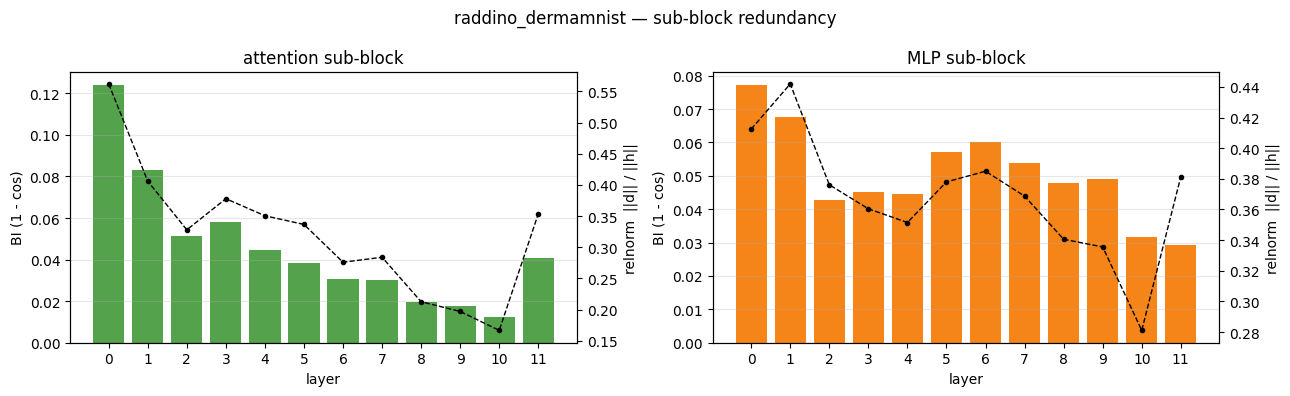

Lowest-BI attention layers (-> attn_skip): [np.int64(10), np.int64(9), np.int64(8), np.int64(7), np.int64(6)]
Lowest-BI MLP layers       (-> mlp_skip):  [np.int64(11), np.int64(10), np.int64(2), np.int64(4), np.int64(3)]


In [42]:
if sub:
    li = sorted(sub)
    bi_attn = [sub[i][0] for i in li]; rn_attn = [sub[i][1] for i in li]
    bi_mlp  = [sub[i][2] for i in li]; rn_mlp  = [sub[i][3] for i in li]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for a, bi, rn, name, col in [(ax[0], bi_attn, rn_attn, "attention", "#54a24b"),
                                 (ax[1], bi_mlp, rn_mlp, "MLP", "#f58518")]:
        a.bar(li, bi, color=col, label="BI")
        a2 = a.twinx(); a2.plot(li, rn, "k.--", lw=1, label="relnorm")
        a.set_title(f"{name} sub-block"); a.set_xlabel("layer")
        a.set_ylabel("BI (1 - cos)"); a2.set_ylabel("relnorm  ||d|| / ||h||")
        a.set_xticks(li); a.grid(axis="y", alpha=.3)
    plt.suptitle(f"{STEM} — sub-block redundancy"); plt.tight_layout(); plt.show()

    print("Lowest-BI attention layers (-> attn_skip):", list(np.argsort(bi_attn)[:5]))
    print("Lowest-BI MLP layers       (-> mlp_skip): ", list(np.argsort(bi_mlp)[:5]))
else:
    print("No sublayer split for this architecture.")

## Angular-distance heatmap + best spans
`d(i, j)` small => hidden states `i` and `j` are close. A skip `(skip_from, skip_to)` bridges hidden states `skip_from+1 -> skip_to+1` (red dots), so dark cells above the diagonal are the cheapest multi-block skips.

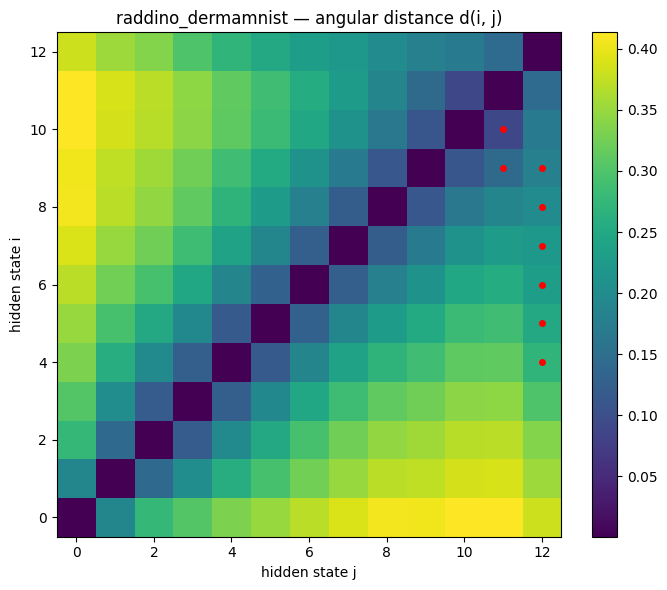

Best placement per number of blocks dropped  (skip = [(skip_from, skip_to)]):
  drop 1 block(s):  skip = [(9, 10)]   angdist = 0.0906   cka = 0.95
  drop 2 block(s):  skip = [(8, 10)]   angdist = 0.1434   cka = 0.87
  drop 3 block(s):  skip = [(8, 11)]   angdist = 0.1806   cka = 0.72
  drop 4 block(s):  skip = [(7, 11)]   angdist = 0.1989   cka = 0.68
  drop 5 block(s):  skip = [(6, 11)]   angdist = 0.2203   cka = 0.65
  drop 6 block(s):  skip = [(5, 11)]   angdist = 0.2319   cka = 0.59
  drop 7 block(s):  skip = [(4, 11)]   angdist = 0.2504   cka = 0.53
  drop 8 block(s):  skip = [(3, 11)]   angdist = 0.2714   cka = 0.46


In [43]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(angdist, cmap="viridis", origin="lower")
ax.set_xlabel("hidden state j"); ax.set_ylabel("hidden state i")
ax.set_title(f"{STEM} — angular distance d(i, j)")
fig.colorbar(im, ax=ax, fraction=.046)

# mark the bridged endpoints (skip_from+1, skip_to+1) of the best span of each length
for k, (s, e, d) in sorted(span.items()):
    ax.plot(e + 1, s + 1, "r.", ms=8)
plt.tight_layout(); plt.show()

print("Best placement per number of blocks dropped  (skip = [(skip_from, skip_to)]):")
for k in sorted(span):
    s, e, d = span[k]
    print(f"  drop {k} block(s):  skip = [({s}, {e})]   angdist = {d:.4f}   cka = {cka[s + 1, e + 1]:.2f}")

## CKA heatmap
For a skip `(skip_from, skip_to)`, high `cka[skip_from+1, skip_to+1]` => try `skip_translator = identity`; low => use `linear`.

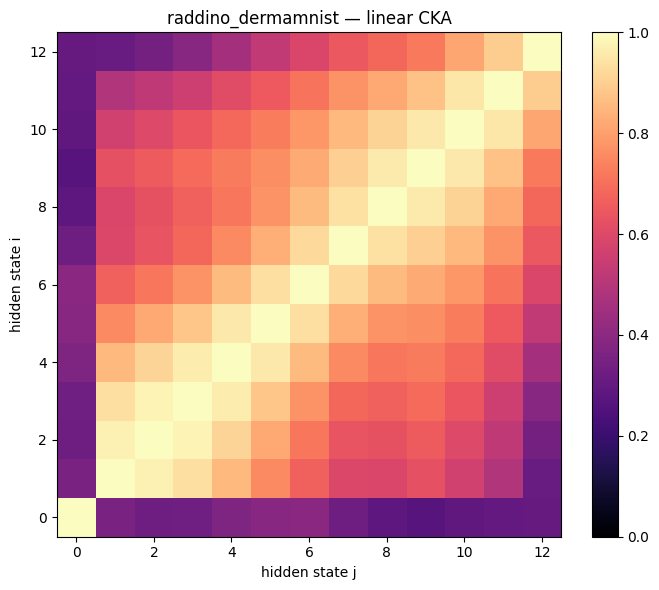

In [44]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cka, cmap="magma", origin="lower", vmin=0, vmax=1)
ax.set_xlabel("hidden state j"); ax.set_ylabel("hidden state i")
ax.set_title(f"{STEM} — linear CKA")
fig.colorbar(im, ax=ax, fraction=.046)
plt.tight_layout(); plt.show()

## Attention-head similarity (JSD)
Per layer, bright off-diagonal cells = redundant head pairs (one of each pair can be pruned).

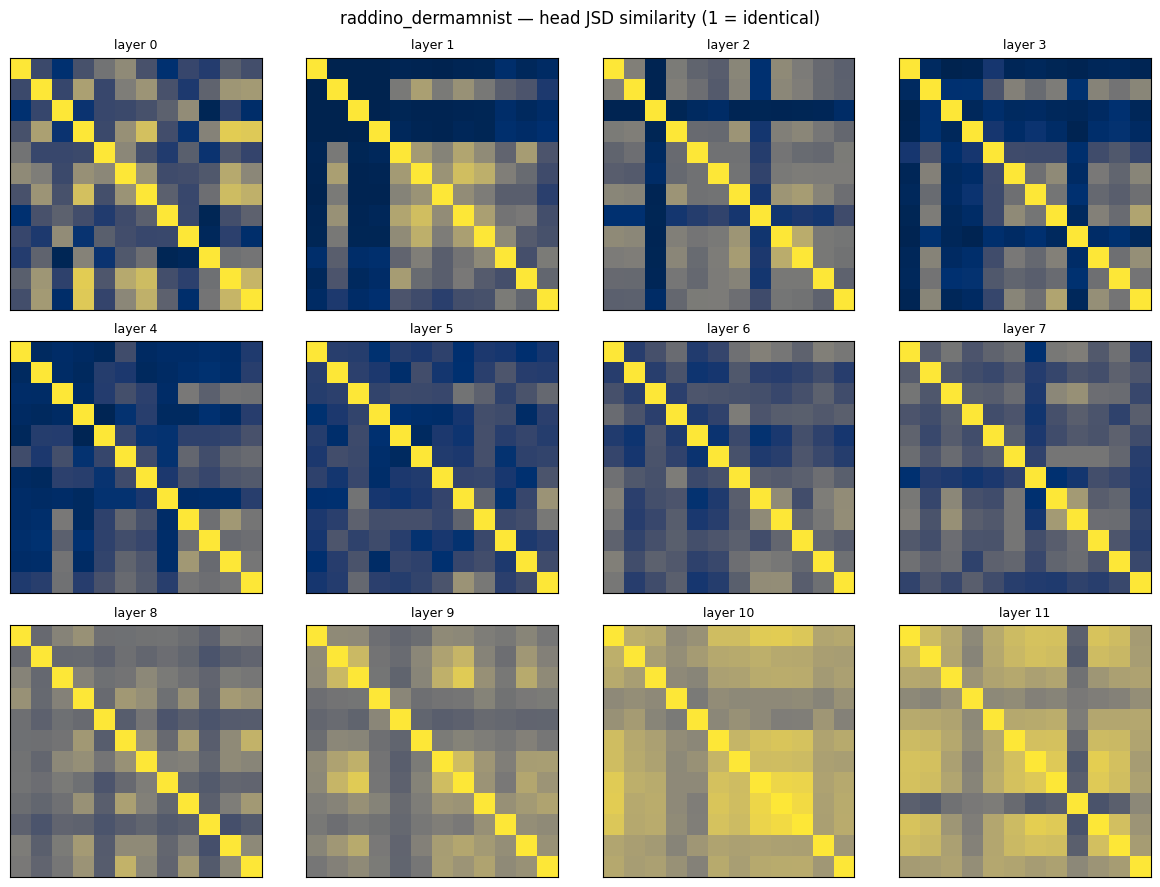

In [45]:
if head_sim is not None:
    L_h, H, _ = head_sim.shape
    cols = 4; rows = (L_h + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    for l, ax in enumerate(axes.ravel()):
        if l < L_h:
            ax.imshow(head_sim[l], cmap="cividis", vmin=0, vmax=1)
            ax.set_title(f"layer {l}", fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis("off")
    plt.suptitle(f"{STEM} — head JSD similarity (1 = identical)"); plt.tight_layout(); plt.show()
else:
    print("No head similarity file (model did not expose attentions).")